### Random Forest Model with SMOTE and Hyperparameter Tuning

#### Elizabeth Greenan

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tabulate import tabulate
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, precision_recall_curve
from scipy.stats import randint

In [2]:
# Read in CSV files from pre-processing
x_train_scaled = pd.read_csv("../Data/x_train.csv")
x_test_scaled = pd.read_csv("../Data/x_test.csv")
y_train = pd.read_csv("../Data/y_train.csv")
y_test = pd.read_csv("../Data/y_test.csv")

In [3]:
# Check that data loaded in (commented out since it was confirmed)
# x_train_scaled.head()
# x_test_scaled.head()
# y_train.head()
# y_test.head()

In [4]:
# Check data shape to ensure there are now only 100 variables
print(y_train.shape)
print(y_test.shape)
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(348433, 1)
(76486, 1)
(348433, 100)
(76486, 100)


In [5]:
# Since Random Forest needs the response variable to be in a 1D array, .squeeze() was applied to both y_test and y_train
# Source: https://www.geeksforgeeks.org/python/numpy-squeeze-in-python/
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Confirm they are now in a 1D array
print(y_train.shape)
print(y_test.shape)

(348433,)
(76486,)


## Cross-Validation and Hyperparameter Tuning

In [6]:
# Run Random Forest model, applying both cross-validation and hyperparameter tuning
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# Source: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html#r001eabbe5dd7-1
# Source: https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# Source (Pipeline modified from this): https://www.kdnuggets.com/why-most-people-misuse-smote-and-how-to-do-it-right
# Source (Grid search modified from this): https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

# Create a pipeline that applies SMOTE to the training dataset only, minimizing the potential for data leakage.
# SMOTE was implemented to fix the severe class imbalance in our target variable, which we think is impacting model performance
# Used the name n_estimators, n_jobs, and random_state as the baseline model so they are comparable
pipeline = Pipeline([
    ('smote', SMOTE(random_state = 123)),
    ('rf', RandomForestClassifier(n_estimators = 100, n_jobs = -1, random_state = 123))
])

# Hyperparameters
# n_estimators: Number of trees
# max_depth: Maximum depth of the tree
# min_samples_split: Minimum number of samples a node must have to be considered for splitting
# min_samples_leaf: Minimum number of samples required in a leaf node
param_grid = {
    'rf__n_estimators': [100], # 100 trees were chosen to balance stability and computational cost
    'rf__max_depth': [10], # 10 was chosen to control complexity and overfitting
    'rf__min_samples_split': [2, 5], # 2 and 5 were chosen as a baseline and to help overfitting
    'rf__min_samples_leaf': [1, 2] # 1 and 2 were chosen as a baseline and to help overfitting
}


# Hyperparameter tuning with GridSearchCV
# GridSearchCV was chosen because it searches over the entire hyperparameter grid
grid_search = GridSearchCV(
    pipeline, # Run the pipeline
    param_grid, # Hyperparameter tuning
    cv=5, # 5 folds
    scoring='f1', # Chosen because target variable is binary
    n_jobs=-1, # Use all processors
    verbose=2 # Produced detailed logs in the output
)

# Fit the model
grid_search.fit(x_train_scaled, y_train)

# Based on the results of the grid_search, find the best performing model
best_model = grid_search.best_estimator_

# Print best parameters and best model
print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best Estimator: Pipeline(steps=[('smote', SMOTE(random_state=123)),
                ('rf',
                 RandomForestClassifier(max_depth=10, min_samples_split=5,
                                        n_jobs=-1, random_state=123))])


In [7]:
# Source: https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

# Make predictions
y_pred = best_model.predict(x_test_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Create table of above results that can go in the report

evaluation_metrics = [
    ["Accuracy:", round(accuracy, 4)],
    ["Precision:", round(precision, 4)],
    ["Recall:", round(recall, 4)],
    ["F1-Score:", round(f1, 4)]
]

print(tabulate(evaluation_metrics, headers = ['Evaluation Metric', 'Value'], tablefmt = 'fancy_grid', showindex = False))

╒═════════════════════╤═════════╕
│ Evaluation Metric   │   Value │
╞═════════════════════╪═════════╡
│ Accuracy:           │  0.8872 │
├─────────────────────┼─────────┤
│ Precision:          │  0.2299 │
├─────────────────────┼─────────┤
│ Recall:             │  0.3909 │
├─────────────────────┼─────────┤
│ F1-Score:           │  0.2895 │
╘═════════════════════╧═════════╛


In [8]:
# Calculate the number of unique values in our response variable, highlighting class imbalance, which is affecting results
y_train.value_counts()

E_Cig_User
0.0    328422
1.0     20011
Name: count, dtype: int64

## Confusion Matrix

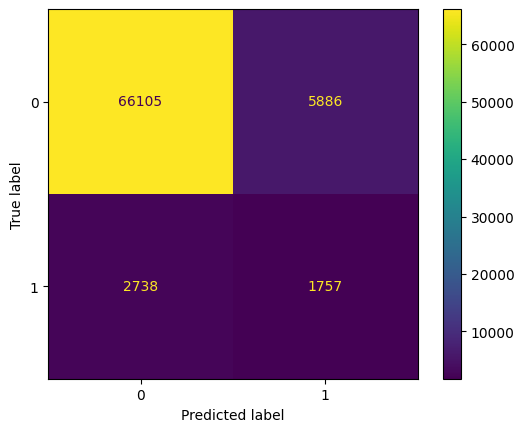

In [9]:
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

# Produce a confusion matrix to evaluate model performance by comparing true and predicted labels. This will be used to compare
# back to the baseline Random Forest model

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

## PR-AUC

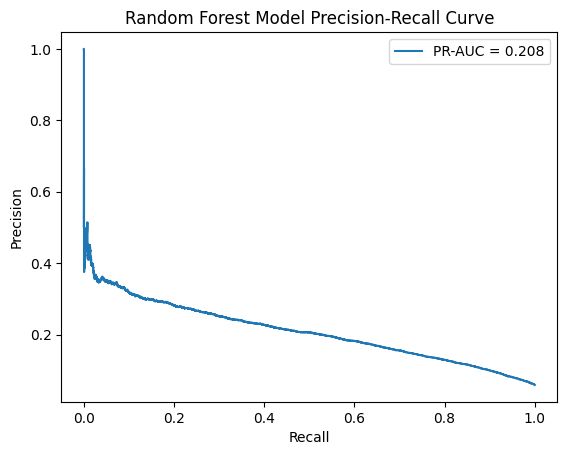

In [10]:
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
# Source: https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html

# Due to the class imbalance, a PR-AUC curve, measuring the precision-recall tradeoff, is a stronger metric. No ROC-AUC was calculated
# for the tuned Random Forest model

y_prob = best_model.predict_proba(x_test_scaled)[:,1] # Calculate probabilities
precision, recall, thresholds = precision_recall_curve(y_test, y_prob) # Calculate the precision-recall curve
pr_auc = average_precision_score(y_test, y_prob) # Calculate the PR-AUC Score

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label = f"PR-AUC = {round(pr_auc, 3)}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Model Precision-Recall Curve")
plt.legend()
plt.show()

## Feature Importance

In [11]:
# Source: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html
# Source: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/

# Calculate the Feature Importance again to see what changed after SMOTE and hyperparameter tuning were applied

importances = best_model.named_steps['rf'].feature_importances_
feature_names = x_train_scaled.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Gini Importance": importances}).sort_values("Gini Importance", ascending = False)
feature_importance.head(10) # Show the first 10 features, which have the highest importance

,Feature,Gini Importance
21,Age_Category_Elderly,0.123881
24,Age_Category_Young_Adult,0.117536
7,Number_of_Days_Last_Month_Poor_Health,0.057803
17,Days_Poor_Mental_Health_0_Days,0.056172
70,Education_College_4_years_or_more_(college_gra...,0.055581
13,Sugar_Soda_Drinks_Per_Day,0.053451
5,Marijuana_Use_30_Days,0.050322
14,Non_Soda_Sugar_Drinks_Per_Day,0.040181
1,Number_of_Children,0.038238
2,Dentist_Visit_Last_Year,0.035808


In [12]:
# Print the first 10 features as a cleaner table for the report
print(tabulate(feature_importance.head(10), headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒══════════════════════════════════════════════════════╤═══════════════════╕
│ Feature                                              │   Gini Importance │
╞══════════════════════════════════════════════════════╪═══════════════════╡
│ Age_Category_Elderly                                 │         0.123881  │
├──────────────────────────────────────────────────────┼───────────────────┤
│ Age_Category_Young_Adult                             │         0.117536  │
├──────────────────────────────────────────────────────┼───────────────────┤
│ Number_of_Days_Last_Month_Poor_Health                │         0.0578034 │
├──────────────────────────────────────────────────────┼───────────────────┤
│ Days_Poor_Mental_Health_0_Days                       │         0.0561717 │
├──────────────────────────────────────────────────────┼───────────────────┤
│ Education_College_4_years_or_more_(college_graduate) │         0.0555812 │
├──────────────────────────────────────────────────────┼───────────────────┤

In [13]:
# Print all features out of curiosity
#print(tabulate(feature_importance, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

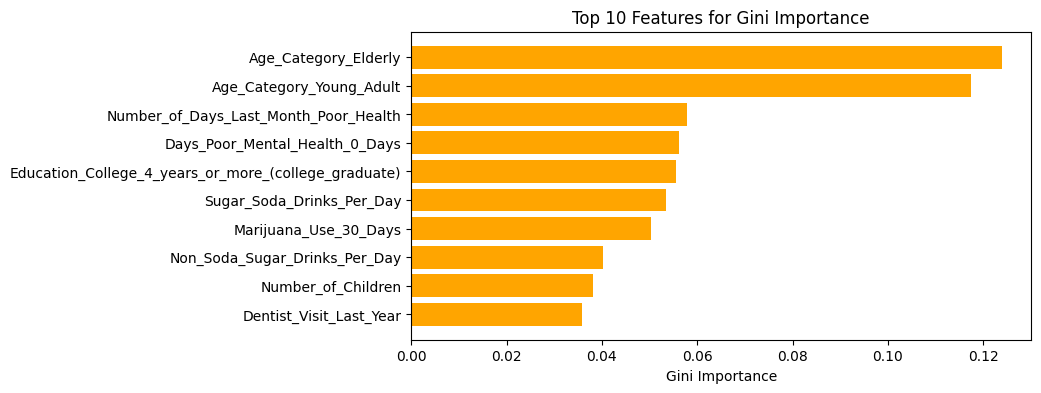

In [14]:
# Plot the top 10 features to see what changed between the baseline and tuned models
# The one-hot encoded age varaibles ahve the top feature importance, which is interesting, since only Age_Category_Middle_Aged was in the
# top 10 for the baseline model

top_10_features = feature_importance.head(10)

plt.figure(figsize= (8,4))
plt.barh(top_10_features["Feature"], top_10_features["Gini Importance"], color = 'orange')
plt.xlabel('Gini Importance')
plt.title('Top 10 Features for Gini Importance')
plt.gca().invert_yaxis() # Inverts y-axis so they are in descending order
plt.show()

In [16]:
# Implement RandomizedSearchCV with updated hyperparameter tuning to see if results improve

In [17]:
# Source: https://codesignal.com/learn/courses/hypertuning-classical-models/lessons/random-search-for-hyperparameter-tuning-in-scikit-learn

# Create a pipeline that applies SMOTE to the training dataset only
pipeline = Pipeline([
    ('smote', SMOTE(random_state = 123)),
    ('rf', RandomForestClassifier(n_estimators = 100, n_jobs = 1, class_weight = "balanced", random_state = 123))
])

# Hyperparameters using randint to pick a random value between the two numbers
param_dist = {
    'rf__n_estimators': randint(100,200), # Number of trees
    'rf__max_depth': randint(10,20), # Maximum depth of the tree
    'rf__min_samples_split': randint(2,5), # Minimum number of samples a node must have to be considered for splitting
    'rf__min_samples_leaf': randint(1,5) # Minimum number of samples required in a leaf node
}


# Hyperparameter tuning with RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline, # Run the pipeline
    param_distributions = param_dist, # Hyperparameter tuning
    n_iter = 5,
    cv=5, # 5 folds
    scoring='f1', # Chosen because target variable is binary
    n_jobs=-1, # Use all processors
    verbose=2 # Produced detailed logs in the output
)

# Fit the model
random_search.fit(x_train_scaled, y_train)

# Find best model during hyperparameter tuning
best_model_random = random_search.best_estimator_

# Print best parameters and best model
print("Best Parameters:", random_search.best_params_)
print("Best Estimator:", random_search.best_estimator_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'rf__max_depth': 11, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 3, 'rf__n_estimators': 147}
Best Estimator: Pipeline(steps=[('smote', SMOTE(random_state=123)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=11,
                                        min_samples_leaf=4, min_samples_split=3,
                                        n_estimators=147, n_jobs=1,
                                        random_state=123))])


In [22]:
# Make predictions
y_pred = best_model_random.predict(x_test_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Create table of above results that can go in the report

evaluation_metrics = [
    ["Accuracy:", round(accuracy, 4)],
    ["Precision:", round(precision, 4)],
    ["Recall:", round(recall, 4)],
    ["F1-Score:", round(f1, 4)]
]

print(tabulate(evaluation_metrics, headers = ['Evaluation Metric', 'Value'], tablefmt = 'fancy_grid', showindex = False))

╒═════════════════════╤═════════╕
│ Evaluation Metric   │   Value │
╞═════════════════════╪═════════╡
│ Accuracy:           │  0.8983 │
├─────────────────────┼─────────┤
│ Precision:          │  0.2433 │
├─────────────────────┼─────────┤
│ Recall:             │  0.3464 │
├─────────────────────┼─────────┤
│ F1-Score:           │  0.2858 │
╘═════════════════════╧═════════╛


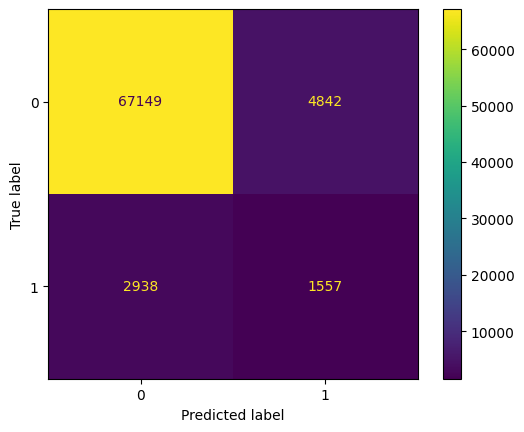

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

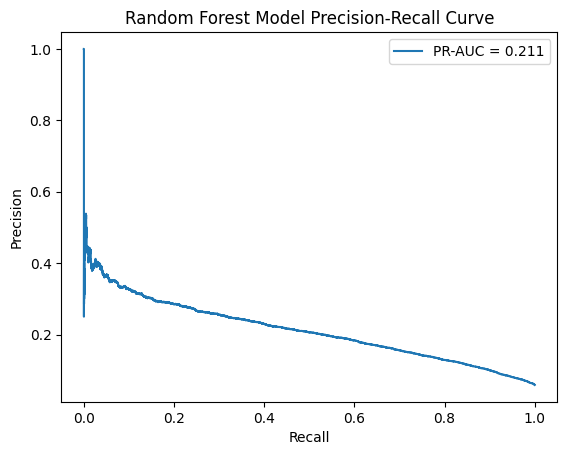

In [24]:
y_prob = best_model_random.predict_proba(x_test_scaled)[:,1] # Calculate probabilities
precision, recall, thresholds = precision_recall_curve(y_test, y_prob) # Calculate the precision-recall curve
pr_auc = average_precision_score(y_test, y_prob) # Calculate the PR-AUC Score

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label = f"PR-AUC = {round(pr_auc, 3)}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Model Precision-Recall Curve")
plt.legend()
plt.show()